In [ ]:
!pip install transformers datasets accelerate kagglehub -U -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.2 MB/s eta 0:00:00


In [ ]:
import kagglehub
import pandas as pd
import os
import torch
from datasets import Dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
path = kagglehub.dataset_download("jessicali9530/kuc-hackathon-winter-2018")

Using Colab cache for faster access to the 'kuc-hackathon-winter-2018' dataset.


In [ ]:

# пути к файлам
train_path = os.path.join(path, [f for f in os.listdir(path) if "Train" in f][0])
test_path = os.path.join(path, [f for f in os.listdir(path) if "Test" in f][0])

# Загружаем
train_df = pd.read_csv(train_path, sep=',', on_bad_lines='skip')
test_df = pd.read_csv(test_path, sep=',', on_bad_lines='skip')

# Убираем лишние пробелы
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

print(train_df.shape[1])
display(train_df.head())


7


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [ ]:
train_df.head(20)

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37
5,155963,Cialis,Benign Prostatic Hyperplasia,"""2nd day on 5mg started to work with rock hard...",2,28-Nov-15,43
6,165907,Levonorgestrel,Emergency Contraception,"""He pulled out, but he cummed a bit in me. I t...",1,7-Mar-17,5
7,102654,Aripiprazole,Bipolar Disorde,"""Abilify changed my life. There is hope. I was...",10,14-Mar-15,32
8,74811,Keppra,Epilepsy,""" I Ve had nothing but problems with the Kepp...",1,9-Aug-16,11
9,48928,Ethinyl estradiol / levonorgestrel,Birth Control,"""I had been on the pill for many years. When m...",8,8-Dec-16,1


In [ ]:
# Проверим, нет ли пустых отзывов
train_df['review'].isnull().sum()

np.int64(0)

In [ ]:
# проверим отзывы
sample_idx = 15
print(f"Пример случайного отзыва (индекс {sample_idx}):")
print(train_df.iloc[sample_idx]['review'])

Пример случайного отзыва (индекс 15):
"I have been taking Saxenda since July 2016.  I had severe nausea for about a month once I got up to the 2.6 dosage.  It has since subsided and the only side effect I notice now is the dry mouth.  I make sure to drink  2.5 litres of water a day (about 10 glasses).  This helps with the weight loss as well as the constipation.  I have been reducing my dose to find a comfortable spot where I am still losing weight but don&#039;t feel like I am over medicating.  For me, 1.8 is working very well.  I also feel wearing a Fitbit has really helped.  I can track my food, water, exercise and steps - it keeps me moving more.  When this started I could barely walk the length of myself without getting winded - I have lost 58 lbs so far."


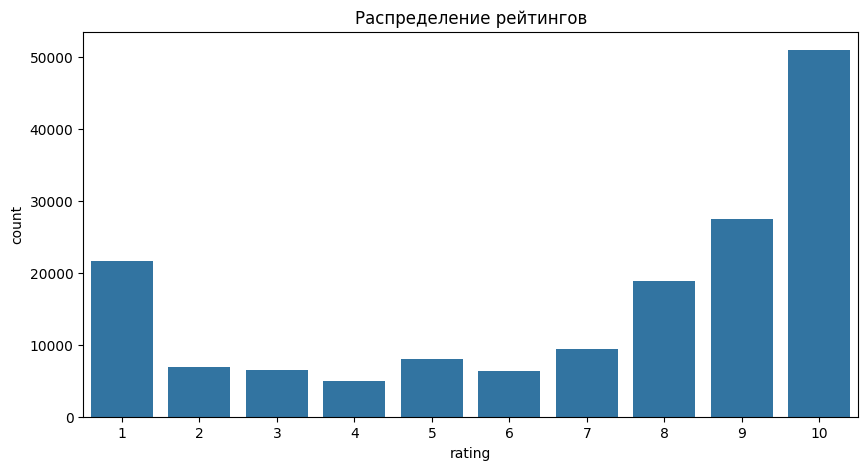

In [ ]:
# гистограмма рейтингов
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='rating')
plt.title('Распределение рейтингов')
plt.show()

In [ ]:
# самый длинный отзыв, чтобы понять, какой max_length ставить
max_len = train_df['review'].str.len().max()
print(max_len)

10787


In [ ]:
# Очистка текста
def clean_text(df):
    df['review'] = df['review'].str.replace('&#039;', "'").str.replace('&quot;', '"').str.strip()
    return df[['review', 'rating']].rename(columns={'rating': 'label'})

train_data = clean_text(train_df)
test_data = clean_text(test_df)

print(len(train_data))

161297


In [ ]:
train_data['label'] = train_data['label'].astype('float32')
test_data['label'] = test_data['label'].astype('float32')

In [ ]:
# обучение
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# формат Hugging Face
ds_train = Dataset.from_pandas(train_data)
ds_test = Dataset.from_pandas(test_data)

def preprocess_function(examples):
    # max_length=128 достаточно для отзывов, чтобы не тормозить
    return tokenizer(examples["review"], truncation=True, padding="max_length", max_length=128)

tokenized_train = ds_train.map(preprocess_function, batched=True, remove_columns=["review"])
tokenized_test = ds_test.map(preprocess_function, batched=True, remove_columns=["review"])


Map:   0%|          | 0/161297 [00:00<?, ? examples/s]

Map:   0%|          | 0/53766 [00:00<?, ? examples/s]

In [ ]:
# Проверим, как отработал токенайзер на случайном примере
example_idx = 2
print(f"Исходный текст: {train_data.iloc[example_idx]['review'][:100]}...")
print(f"Токены: {tokenized_train[example_idx]['input_ids'][:20]}")
print(f"Декодированные токены: {tokenizer.decode(tokenized_train[example_idx]['input_ids'][:20])}")


Исходный текст: "I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light ...
Токены: [101, 1000, 1045, 2109, 2000, 2202, 2178, 8700, 24528, 28687, 1010, 2029, 2018, 2538, 17357, 5402, 1010, 1998, 2001, 2200]
Декодированные токены: [CLS] " i used to take another oral contraceptive, which had 21 pill cycle, and was very


In [ ]:
# Загружаем модель для регрессии
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1)

# Проверка каждые 1000 шагов
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=1000,
    save_steps=1000,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=1,
    weight_decay=0.01,
    fp16=True,
    logging_dir='./logs',
    report_to="none"
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    mse = mean_squared_error(labels, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(labels, predictions)
    return {"rmse": rmse, "mae": mae, "mse": mse}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

trainer.train()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss,Validation Loss,Rmse,Mae,Mse
1000,4.733837,4.329328,2.080704,1.444905,4.329328
2000,3.915434,3.531430,1.879210,1.302806,3.531431
3000,3.608233,3.299966,1.816581,1.254321,3.299966
4000,3.401778,3.214463,1.792892,1.215457,3.214463
5000,3.288635,3.112212,1.764146,1.185829,3.112212


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5041, training_loss=4.331182905521405, metrics={'train_runtime': 1027.2091, 'train_samples_per_second': 157.025, 'train_steps_per_second': 4.907, 'total_flos': 5341553239536384.0, 'train_loss': 4.331182905521405, 'epoch': 1.0})

In [ ]:
# Валидация модели на тестовом примере
test_review = "I had high hopes for this treatment, but unfortunately the side effects were too much for me. It works, but I can't take it anymore"

In [ ]:
# Токенизация
inputs = tokenizer(test_review, return_tensors="pt", truncation=True, padding=True, max_length=128).to("cuda")
model.to("cuda")

model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    prediction = outputs.logits.item()

final_rating = max(1, min(10, prediction))

print(f"Текст отзыва: {test_review}")
print(f"Сырой выход модели (логит): {prediction:.4f}")
print(f"Предсказанный рейтинг (1-10): {final_rating:.2f}")

Текст отзыва: I had high hopes for this treatment, but unfortunately the side effects were too much for me. It works, but I can't take it anymore
Сырой выход модели (логит): 5.0820
Предсказанный рейтинг (1-10): 5.08


In [ ]:
# Интерпретация результата
if final_rating >= 7:
    sentiment = "Положительный"
elif final_rating <= 4:
    sentiment = "Отрицательный"
else:
    sentiment = "Нейтральный"

print(f"Классификация: {sentiment}")

Классификация: Нейтральный


Выводы

Использованая предобученная модель DistilBERT,
 успешно обучена за 1 эпоху. Итоговая ошибка MAE составила 1.18, а RMSE 1.76. Плавное снижение Validation Loss подтверждает стабильность обучения.
 Пример с отзывом показывает, что модель адекватно обрабатывает контекст

 Модель готова к использованию для автоматической модерации и анализа тональности отзывов